In [77]:
# ------------------------------------------------------------
# Cutthroat: A Topology Optimization Framework
# Author: John A. Gardiner
# ------------------------------------------------------------

# This code is part of the Cutthroat topology optimization framework, which is designed to optimize material distribution in heat exchangers for improved performance. The framework includes mesh generation, finite element analysis, and optimization algorithms. The following code snippet focuses on the simulation of meshes and the integration of a neural network for predicting optimal material distributions.

In [78]:
# -------------------------------------------------------------
# Libraries and Imports
# -------------------------------------------------------------

# Paths and File Handling
import os
import subprocess
from pathlib import Path
from jinja2 import Template
import json
import uuid
from dataclasses import dataclass, field, asdict
from typing import Optional
import gmsh

# Numerical and Visualization Libraries
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

# Neural Network and Machine Learning Libraries
import torch
import torch.nn as nn
from scipy.ndimage import label
from concurrent.futures import ThreadPoolExecutor

In [79]:
# -------------------------------------------------------------
# Torch Device Configuration
# -------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU


In [80]:
# -------------------------------------------------------------
# Supporting Geometry Generation Classes and Data Structures
# -------------------------------------------------------------

@dataclass
class GeometryConfig:
    """
    Serializable snapshot of a heat exchanger geometry.
    
    Produced by the Generator and consumed by both the MeshGenerator (to build the .msh file)
    and the Optimizer (to map simulation results back onto the original grid).
    
    Fields:
    -------
    grid_nx, grid_ny: int
        Number of grid points in the x and y directions for the reference grid.
    domain_length, domain_height: float
        Physical dimensions of the rectangular fluid domain.
    occupancy_grid : list[list[float]]
        2D list representing the occupancy of the domain, where 0 indicates solid and 1 indicates fluid.Soft (0-1) CNN output before thresholding. Shape: (grid_ny, grid_nx).
        Stored so the CNN state can be reproduced exactly for the same geometry, and so the optimizer can use the same grid for mapping results back to the original geometry.
    obstacle_polygons : list[list[tuple[float, float]]]
        List of polygons representing the obstructions in the geometry. Each polygon is a list of (x, y) coordinates of its vertices.
    config_id : str
        UUID assigned at creation - ties a GeometryConfig to its .msh file and simulation results for reproducibility and traceability.
    """

    grid_nx: int
    grid_ny: int
    domain_length: float
    domain_height: float
    occupancy_grid: list # shape (grid_ny, grid_nx), values between 0 and 1
    obstacle_polygons: list # list of polygons, where each polygon is a list of (x, y) vertex coordinates
    config_id: str = field(default_factory=lambda: str(uuid.uuid4()))

    # Serialization
    def save(self, path: str | Path) -> None:
        """Save to a JSON file. Mesh files use the same config_id stem."""
        with open(path, "w") as f:
            json.dump(asdict(self), f, indent=2)
    
    @classmethod
    def load(cls, path: str | Path) -> "GeometryConfig":
        with open(path) as f:
            data = json.load(f)
        return cls(**data)
    
    @property
    def mesh_filename(self) -> str:
        """Canonical filename derived from config_id."""
        return f"hx_{self.config_id}.msh"
    
    def grid_cell_size(self) -> tuple[float, float]:
        """Physical size of each grid cell (dx, dy)."""
        return (self.domain_length / self.grid_nx, self.domain_height / self.grid_ny)
    
    def cell_center(self, ix: int, iy: int) -> tuple[float, float]:
        """
        Physical (x, y) coordinates of the center of grid cell (ix, iy).
        ix in [0, grid_nx), iy in [0, grid_ny).
        Origin is at the bottome left of the domain
        """
        dx, dy = self.grid_cell_size()
        x = (ix + 0.5) * dx
        y = (iy + 0.5) * dy - self.domain_height / 2
        return (x, y)
    
class HeatExchanger:
    """
    Contains the geometry, mesh, and simulation results for a single heat exchanger design. This is the main data structure that the Generator produces and the Optimizer consumes.

    Parameters:
    id: str
        Unique identifier for this heat exchanger design, typically derived from the GeometryConfig's config_id.
    config_filename: Optional[str]
        Path to the GeometryConfig JSON file that describes the geometry of this heat exchanger. This file is used to generate the mesh and to map simulation results back to the original grid.
    mesh_filename: Optional[str]
        Path to the GMSH .msh file that contains the mesh for this heat exchanger design. This file is generated from the GeometryConfig and is used as input for the simulation.
    result_filename: Optional[str]
        Path to the simulation results file (e.g., Exodus .e file) for this heat exchanger design. This file is generated by running the simulation on the mesh and contains the results that will be analyzed and used for optimization.
    geometry_config: Optional[GeometryConfig]
        An instance of GeometryConfig that describes the geometry of this heat exchanger. This is typically loaded from the config_filename and is used for reference throughout the optimization process.
    obstruction_polygons: Optional[list]
        A list of polygons representing the obstructions in the geometry, extracted from the occupancy grid. Each polygon is a list of (x, y) coordinates of its vertices. This is derived from the GeometryConfig and is used for mesh generation and visualization.
    solved: bool
        A flag indicating whether the simulation for this heat exchanger design has been run and results are available. This is used to track the state of the optimization process.
    results: Optional[dict]
        A dictionary containing the analyzed results from the simulation, such as temperature distribution, flow patterns, and performance metrics. This is derived from the result_filename and is used for optimization and decision-making.
    """
    
    def __init__(
        self,
        id: str,
        mesh_params: dict,
        geometry_config: Optional[GeometryConfig] = None,
    ):
        self.id = id
        self.mesh_params = mesh_params
        self.config_filename = None
        self.mesh_filename = None
        self.result_filename = None
        self.set_filenames()
        
        # Load geometry config and extract obstruction polygons
        self.geometry_config = geometry_config
        self.obstruction_polygons = None
        if geometry_config is None:
            self.load_geometry_config()
        else:
            self.obstruction_polygons = self.geometry_config.obstacle_polygons

        # Check for existing mesh and results
        self.mesh_exists = self.check_for_mesh()
        
        # Simulation state
        self.results = None
        self.solved = self.check_for_existing_results()
    
    def set_filenames(self):
        """Set the mesh_filename and result_filename based on the heat exchanger ID."""
        self.config_filename = f"configs/hx_{self.id}.json"
        self.mesh_filename = f"meshes/hx_{self.id}.msh"
        self.result_filename = f"results/hx_{self.id}.e"

    def load_geometry_config(self):
        """Load the GeometryConfig from the config_filename."""
        self.geometry_config = GeometryConfig.load(self.config_filename)
        self.obstruction_polygons = self.geometry_config.obstacle_polygons

    def check_for_mesh(self) -> bool:
        """Check if the mesh file already exists for this heat exchanger design."""
        if os.path.exists(self.mesh_filename):
            return True
        else:
            self.generate_mesh()
        return os.path.exists(self.mesh_filename)

    def check_for_existing_results(self) -> bool:
        """Check if the result file already exists for this heat exchanger design."""
        if os.path.exists(self.result_filename):
            self.read_results()
        return os.path.exists(self.result_filename)
    
    def read_results(self):
        """Read the simulation results from the result_filename and store them in self.results."""
        # Placeholder for reading results - this would depend on the format of the results file
        self.results = None

    def create_custom_obstruction(self, points: list[tuple[float, float]]) -> int:
        """
        Create a planar surface in GMSH from an ordered list of (x, y) points.
        Returns the GMSH surface tag.
        """
        n_points = len(points)
        gmsh_points = []
        for coord in points:
            pt = gmsh.model.occ.addPoint(coord[0], coord[1], 0)
            gmsh_points.append(pt)
 
        lines = []
        for i in range(n_points):
            line = gmsh.model.occ.addLine(
                gmsh_points[i],
                gmsh_points[(i + 1) % n_points],
            )
            lines.append(line)
 
        cl = gmsh.model.occ.addCurveLoop(lines)
        surface = gmsh.model.occ.addPlaneSurface([cl])
        return surface

    def generate_mesh(self) -> str:
        """
        Returns the path to the written .msh file.
        """
        gmsh.initialize()
        gmsh.model.add(f"hx_{self.id}")
 
        rect = gmsh.model.occ.addRectangle(
            0, 0, 0,
            self.geometry_config.domain_length, self.geometry_config.domain_height,
        )
        gmsh.model.occ.synchronize()
 
        obstructions = []
        for polygon in self.obstruction_polygons:
            surface = self.create_custom_obstruction(polygon)
            obstructions.append(surface)
        gmsh.model.occ.synchronize()
 
        if obstructions:
            cut = gmsh.model.occ.cut(
                [(2, rect)],
                [(2, s) for s in obstructions],
                removeObject=True,
                removeTool=True,
            )
            gmsh.model.occ.synchronize()
            out_dim_tags, _ = cut
            fluid_surfaces = [tag for dim, tag in out_dim_tags if dim == 2]
        else:
            # No obstacles — entire rectangle is the fluid domain
            fluid_surfaces = [rect]
 
        if not fluid_surfaces:
            gmsh.finalize()
            raise RuntimeError(
                "Boolean cut produced no fluid domain. "
                "Check that obstacles don't fill the entire domain."
            )
 
        gmsh.model.addPhysicalGroup(2, fluid_surfaces, name="Fluid")

        # Boundary classification
        gmsh.model.occ.synchronize()
        boundaries = gmsh.model.getBoundary(
            [(2, s) for s in fluid_surfaces], oriented=False
        )
 
        wall_curves, inlet, outlet, top, bottom = [], [], [], [], []
        for dim, tag in boundaries:
            x, y, _ = gmsh.model.occ.getCenterOfMass(dim, tag)
            if abs(x) < 1e-6:
                inlet.append(tag)
            elif abs(x - self.geometry_config.domain_length) < 1e-6:
                outlet.append(tag)
            elif abs(y - self.geometry_config.domain_height / 2) < 1e-6:
                top.append(tag)
            elif abs(y + self.geometry_config.domain_height / 2) < 1e-6:
                bottom.append(tag)
            else:
                wall_curves.append(tag)
 
        if wall_curves:
            gmsh.model.addPhysicalGroup(1, wall_curves, name="Wall")
        if inlet:
            gmsh.model.addPhysicalGroup(1, inlet, name="Inlet")
        if outlet:
            gmsh.model.addPhysicalGroup(1, outlet, name="Outlet")
        if top:
            gmsh.model.addPhysicalGroup(1, top, name="Top")
        if bottom:
            gmsh.model.addPhysicalGroup(1, bottom, name="Bottom")
 
        p = self.mesh_params
        gmsh.option.setNumber("Mesh.CharacteristicLengthMin", p["mesh_min"])
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", p["mesh_max"])
        gmsh.option.setNumber("Mesh.Algorithm",               p["mesh_algorithm"])
        gmsh.option.setNumber("Mesh.RecombineAll",             p["mesh_recombine"])
        gmsh.option.setNumber("Mesh.ElementOrder",             p["mesh_element_order"])
 
        gmsh.model.mesh.generate(2)
        gmsh.write(self.mesh_filename)
        gmsh.finalize()

        return self.mesh_filename
    
class HeatExchangerCNN(nn.Module):
    """
    Maps a latent vector z -> occupancy grid of shape (1, grid_ny, grid_nx).

    The output is passed through sigmoid so values are in (0, 1).
    During training, keep the soft output for RL policy log-probs.
    For geometry generation, threshold at 'threshold' to get binary cells,
    then extract connected blobs as obstacle polygons.

    Architecture: fully-connected projection -> reshape -> series of 
    transposed conv upsampling blocks. The final spatial size is determined by grid_nx and grid_ny
    - the network is built to match these exactly.    
    """

    def __init__(
            self,
            latent_dim: int = 32,
            grid_nx: int = 20,
            grid_ny: int = 10,
            base_channels: int = 64,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.base_channels = base_channels

        # Project z to a small spatial feature map, then upsample.
        # We start at (base_channels, 2, 2) and double the spatial dims each block.
        # Number of upsampling blocks needed:
        self._n_ups_x = int(np.ceil(np.log2(grid_nx))) - 1 # number of doublings needed
        self._n_ups_y = int(np.ceil(np.log2(grid_ny))) - 1
        n_blocks = max(self._n_ups_x, self._n_ups_y)

        # FC projection
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 4),
            nn.ReLU(),
            nn.Linear(base_channels * 4, base_channels * 2 * 2),
            nn.ReLU()
        )
        self.init_channels = base_channels
        self.init_h = 2
        self.init_w = 2

        # Upsampling blocks
        blocks = []
        in_ch = base_channels
        for i in range(n_blocks):
            out_ch = max(in_ch // 2, 8)
            blocks.append(nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ))
            in_ch = out_ch
        self.ups = nn.ModuleList(blocks)

        # Final 1x1 conv to singe-channel occupancy grid
        self.head = nn.Conv2d(in_ch, 1, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Parameters:
        z: Tensor of shape (B, latent_dim)
        
        Returns: 
        Tensor of shape (B, 1, grid_ny, grid_nx) occupancy grid with values in (0, 1)
        """
        B = z.shape[0]
        x = self.fc(z) # (B, base_channels * 2 * 2)
        x = x.view(B, self.init_channels, self.init_h, self.init_w) # (B, base_channels, 2, 2)

        for up in self.ups:
            x = up(x) # upsample
        x = self.head(x) # (B, 1, H, W)
        
        # Crop or interpolate to extract target size
        x = torch.nn.functional.interpolate(
            x, size=(self.grid_ny, self.grid_nx), mode='bilinear', align_corners=False
            )
        x = torch.sigmoid(x) # values in (0, 1)
        return x
    
class GeometryFilter:
    """
    Validates an occupancy grid before committing to mesh generation.

    Checks
    ------
    1. Solid density: fraction of solid cells must be within [min_density, max_density].
    2. Flow path: at least one continuous fluid path from inlet (left) to outlet (right).
    3. No enclosed fluid: every fluid region must connect to both the inlet and outlet boundaries.
       Fluid pockets fully surrounded by solid are rejected.

    Parameters
    ----------
    min_density, max_density : float
        Solid fraction bounds.
    threshold : float
        Binarization threshold, should match HeatExchangerGenerator.
    """

    def __init__(
        self,
        min_density: float = 0.10,
        max_density: float = 0.75,
        threshold: float = 0.5,
    ):
        self.min_density = min_density
        self.max_density = max_density
        self.threshold = threshold

    def is_valid(self, occupancy: np.ndarray) -> tuple[bool, dict]:
        binary = (occupancy >= self.threshold)

        density_ok, density_val = self._check_density(binary)
        flow_ok                 = self._check_flow_path(binary)
        no_pockets              = self._check_no_enclosed_fluid(binary)

        report = {
            "solid_density":      round(float(density_val), 4),
            "density_ok":         density_ok,
            "has_flow_path":      flow_ok,
            "no_enclosed_fluid":  no_pockets,
            "valid":              density_ok and flow_ok and no_pockets,
        }
        return report["valid"], report

    def _check_density(self, binary: np.ndarray) -> tuple[bool, float]:
        density = binary.mean()
        return self.min_density <= density <= self.max_density, density

    def _check_flow_path(self, binary: np.ndarray) -> bool:
        fluid = ~binary
        if not fluid[:, 0].any() or not fluid[:, -1].any():
            return False
        labeled, n = label(fluid, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        for comp_id in range(1, n + 1):
            region = labeled == comp_id
            if region[:, 0].any() and region[:, -1].any():
                return True
        return False

    def _check_no_enclosed_fluid(self, binary: np.ndarray) -> bool:
        """
        Check that no fluid region is fully enclosed by solid.

        A fluid region is considered enclosed if it does not touch the inlet
        and outlet boundaries. Touching both boundaries means the fluid is reachable 
        from outside the heat exchanger, which is the physical requirement.
        """
        fluid = ~binary
        labeled, n = label(fluid, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        for comp_id in range(1, n + 1):
            region = labeled == comp_id
            touches_boundary = (
                region[:, 0].any()   and   # left column (inlet)
                region[:, -1].any()       # right column (outlet)
            )
            if not touches_boundary:
                return False
        return True
    
class FilterLoss(nn.Module):
    """
    Differentiable proxy for all three hard GeometryFilter checks. 
    Additionally, includes extra terms to encourage desirable properties like diversity, tortuosity, fragmentation, fine channel structure, sharp interfaces, and non-periodicity — all of which are common failure modes when training a CNN with only the basic filter checks as supervision.

    Parameters
    ----------
    min_density, max_density : float
        Target solid fraction bounds.
    density_weight : float
        Weight for the density loss term. Since density is a fundamental constraint, this should be set high enough to strongly penalize designs that are too sparse or too dense.
    flow_weight : float
        Weight for the flow path loss term. Since a clear flow path is critical, this should be set high to strongly penalize designs that block the inlet or outlet.
    pocket_weight : float
        Weight for the enclosed fluid loss term. Since enclosed fluid is a hard fail, this should be set high to strongly penalize any pockets.
    diversity_weight : float
        Weight for the diversity loss term, which encourages variation in the generated geometries across a batch of latent vectors.
    diversity_min_std : float
        Minimum standard deviation for the diversity loss term. If the standard deviation of the occupancy grids in a batch falls below this threshold, the diversity loss will increase to encourage more variation.
    tortuosity_weight : float
        Weight for the tortuosity loss term, which encourages more tortuous flow paths to break up straight channels that can cause periodic patterns.
    min_tortuosity : float
        Minimum tortuosity for the tortuosity loss term. If the tortuosity of the flow paths in a generated geometry falls below this threshold, the tortuosity loss will increase to encourage more winding paths.
    fragmentation_weight : float
        Weight for the fragmentation loss term, which discourages large blocks of solid or fluid and encourages more, smaller channels.
    channel_scale_weight : float
        Weight for the channel scale loss term, which encourages finer channel structures by penalizing deviations from a target channel width.
    target_channel_width : float
        Target channel width for the channel scale loss term. This pushes the generator toward producing features of a certain size, which can help avoid overly large solid blocks or wide fluid channels.
    interface_weight : float
        Weight for the interface loss term, which encourages sharper solid-fluid interfaces by penalizing intermediate occupancy values and promoting more binary-like outputs.
    periodicity_weight : float
        Weight for the periodicity loss term, which discourages periodic patterns in the generated geometries by penalizing repeating structures in the occupancy grid.
    """

    def __init__(
        self,
        min_density: float = 0.20,
        max_density: float = 0.80,
        density_weight: float = 2.5,            # increase to more strongly penalize densities outside the valid range
        flow_weight: float = 2.0,               # increase to strongly encourage a clear flow path
        pocket_weight: float = 14.0,            # enclosed fluid is a hard fail, increase to punish it more heavily
        diversity_weight: float = 2.0,          # increase to encourage more diversity in the batches
        diversity_min_std: float = 0.25,
        tortuosity_weight: float = 0.0,         # encourage tortuosity to break up straight channels that can cause periodic patterns
        min_tortuosity: float = 0.05, 
        fragmentation_weight: float = 2.0,      # increase to discourage large blocks of solid or fluid — encourages more, smaller channels
        channel_scale_weight: float = 4.0,      # increase to encourage fine structure
        target_channel_width: float = 0.3,      # pushes toward finer features
        interface_weight: float = 4.5,          # increase to encourage sharper solid-fluid interfaces
        periodicity_weight: float = 0.25,       # increase to discourage periodic patterns 
    ):
        super().__init__()
        self.min_density = min_density
        self.max_density = max_density
        self.density_weight = density_weight
        self.flow_weight = flow_weight
        self.pocket_weight = pocket_weight
        self.diversity_weight = diversity_weight
        self.diversity_min_std = diversity_min_std
        self.tortuosity_weight = tortuosity_weight
        self.min_tortuosity = min_tortuosity
        self.fragmentation_weight = fragmentation_weight
        self.channel_scale_weight = channel_scale_weight
        self.target_channel_width = target_channel_width
        self.interface_weight = interface_weight
        self.periodicity_weight = periodicity_weight

    def forward(self, soft_grid):
        density_loss        = self._density_loss(soft_grid)
        flow_loss           = self._flow_loss(soft_grid)
        pocket_loss         = self._pocket_loss(soft_grid)
        diversity_loss      = self._diversity_loss(soft_grid, self.diversity_min_std)
        tortuosity_loss     = self._tortuosity_loss(soft_grid, self.min_tortuosity)
        fragmentation_loss  = self._fragmentation_loss(soft_grid)
        channel_scale_loss  = self._channel_scale_loss(soft_grid, self.target_channel_width)
        interface_loss      = self._interface_loss(soft_grid)
        periodicity_loss    = self._periodicity_loss(soft_grid)

        total = (
            self.density_weight         * density_loss          +
            self.flow_weight            * flow_loss             +
            self.pocket_weight          * pocket_loss           +
            self.diversity_weight       * diversity_loss        +
            self.tortuosity_weight      * tortuosity_loss       +
            self.fragmentation_weight   * fragmentation_loss    +
            self.channel_scale_weight   * channel_scale_loss    +
            self.interface_weight       * interface_loss        +
            self.periodicity_weight     * periodicity_loss
        )
        breakdown = {
            "density_loss":         density_loss.item(),
            "flow_loss":            flow_loss.item(),
            "pocket_loss":          pocket_loss.item(),
            "diversity_loss":       diversity_loss.item(),
            "tortuosity_loss":      tortuosity_loss.item(),
            "fragmentation_loss":   fragmentation_loss.item(),
            "channel_scale_loss":   channel_scale_loss.item(),
            "interface_loss":       interface_loss.item(),
            "periodicity_loss":     periodicity_loss.item(),
            "total_loss":           total.item(),
        }
        return total, breakdown

    def _density_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        density_soft = soft_grid.mean(dim=[1, 2, 3])

        too_low_soft  = torch.relu(self.min_density - density_soft) ** 2
        too_high_soft = torch.relu(density_soft - self.max_density) ** 2
        hinge_loss = (too_low_soft + too_high_soft).mean()

        target = (self.min_density + self.max_density) / 2.0
        pull_loss = (
            torch.relu(self.min_density - density_soft)
            * torch.abs(density_soft - target)
        ).mean()

        # Straight-through hard density
        binary = (soft_grid >= 0.5).float()
        binary_ste = soft_grid + (binary - soft_grid).detach()
        density_hard = binary_ste.mean(dim=[1, 2, 3])
        too_low_hard  = torch.relu(self.min_density - density_hard) ** 2
        too_high_hard = torch.relu(density_hard - self.max_density) ** 2
        hard_loss = (too_low_hard + too_high_hard).mean()

        # Binarization sharpening: penalize values in the ambiguous zone (0.3, 0.7).
        # Pushes sigmoid outputs toward 0 or 1, making hard density match soft density.
        # Without this, the network can satisfy soft density targets while keeping
        # all values just below 0.5, giving hard density near zero.
        ambiguous = torch.relu(soft_grid - 0.3) * torch.relu(0.7 - soft_grid)
        sharpening_loss = ambiguous.mean() * 4.0  # scale: max value is 0.01 at 0.5

        return hinge_loss + pull_loss + hard_loss + sharpening_loss

    def _flow_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes designs that lack a clear flow path from inlet to outlet.

        Switched to isotropic 3x3 kernel to remove horizontal stripe bias.
        """
        fluid = 1.0 - soft_grid

        inlet_blocking  = (1.0 - fluid[:, :, :, 0]).mean()
        outlet_blocking = (1.0 - fluid[:, :, :, -1]).mean()
        column_loss = inlet_blocking + outlet_blocking

        # Isotropic kernel — no directional bias
        kernel = torch.ones(1, 1, 3, 3, device=soft_grid.device) / 9.0
        neighbor_fluid = torch.nn.functional.conv2d(fluid, kernel, padding=1)
        connectivity_loss = torch.relu(fluid - neighbor_fluid).mean()

        return column_loss + connectivity_loss

    def _pocket_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Penalizes fluid cells that are isolated from the domain boundary.

        Strategy: a fluid cell that is far from any boundary is likely
        part of an enclosed pocket. We approximate boundary connectivity
        using a distance-weighted penalty — fluid cells near the center
        of a solid cluster are penalized more than those near an edge.

        This is done in two steps:
        1. Compute a "boundary proximity" map: cells near any domain edge
           get high values, interior cells get low values.
        2. Penalize fluid cells (high soft_grid = solid, so low fluid value)
           that have low boundary proximity AND are surrounded by solid.
        """
        fluid = 1.0 - soft_grid  # (B, 1, grid_ny, grid_nx)
        B, _, H, W = fluid.shape

        # Build boundary proximity map — 1.0 at edges, decaying inward.
        # Uses the minimum normalized distance to any of the four edges.
        device = soft_grid.device
        y_idx = torch.arange(H, device=device).float()
        x_idx = torch.arange(W, device=device).float()

        dist_top    = y_idx / (H - 1)           # 0 at top row, 1 at bottom
        dist_bottom = 1.0 - dist_top             # 0 at bottom row, 1 at top
        dist_left   = x_idx / (W - 1)           # 0 at left col, 1 at right
        dist_right  = 1.0 - dist_left            # 0 at right col, 1 at left

        # Proximity = 1 at boundary, 0 at maximum interior distance
        proximity = torch.minimum(
            torch.minimum(dist_top.unsqueeze(1), dist_bottom.unsqueeze(1)),
            torch.minimum(dist_left.unsqueeze(0), dist_right.unsqueeze(0))
        )  # (H, W)
        # Invert: high value = far from boundary = interior
        interior_weight = (1.0 - proximity).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

        # Penalize fluid cells in the interior that are surrounded by solid.
        # A fluid cell surrounded by solid will have low average neighbor fluid value.
        kernel = torch.ones(1, 1, 3, 3, device=device) / 9.0
        neighbor_fluid = torch.nn.functional.conv2d(fluid, kernel, padding=1)

        # Isolated fluid = fluid cell with low fluid neighbors = likely a pocket
        isolated = fluid * torch.relu(0.5 - neighbor_fluid)

        # Weight by interior distance so boundary-adjacent fluid isn't penalized
        pocket_penalty = (isolated * interior_weight).mean()

        return pocket_penalty
    
    def _diversity_loss(
        self,
        soft_grid: torch.Tensor,
        min_std: float = 0.15,
    ) -> torch.Tensor:
        """
        Penalizes mode collapse by encouraging two kinds of diversity:

        1. Spatial variance within each sample — the occupancy values should
        vary across the grid, not be uniform. A collapsed CNN produces
        nearly identical values everywhere (e.g. all ~0.5), giving near-zero
        spatial std. We penalize when per-sample std drops below min_std.

        2. Inter-sample variance across the batch — different latent vectors
        should produce different grids. If all samples in a batch look the
        same, the mean of the batch looks like any individual sample, so the
        std across samples is near zero. We penalize that too.

        Parameters
        ----------
        soft_grid : Tensor of shape (B, 1, grid_ny, grid_nx)
        min_std : float
            Minimum acceptable std. Values below this are penalized.
            0.15 is a reasonable starting point — pure noise has std ~0.29,
            a fully collapsed output has std ~0.0.
        """
        # 1. Spatial variance: std across spatial dims for each sample
        spatial_std = soft_grid.std(dim=[2, 3])          # (B, 1)
        spatial_loss = torch.relu(min_std - spatial_std).mean()

        # 2. Inter-sample variance: std across batch dim at each spatial location
        if soft_grid.shape[0] > 1:
            batch_std = soft_grid.std(dim=0)             # (1, grid_ny, grid_nx)
            batch_loss = torch.relu(min_std - batch_std).mean()
        else:
            batch_loss = torch.tensor(0.0, device=soft_grid.device)

        return spatial_loss + batch_loss

    def _tortuosity_loss(
        self,
        soft_grid: torch.Tensor,
        min_tortuosity: float = 0.3,
    ) -> torch.Tensor:
        """
        Penalizes designs where fluid flows too directly from inlet to outlet.

        Tortuosity is approximated by measuring vertical variation in the
        fluid distribution across x-slices. A straight horizontal channel
        has the same fluid pattern at every x position (low variation).
        A snaking channel shifts up and down across x positions (high variation).

        Specifically: for each x column, compute the center of mass of the
        fluid cells in y. A path that snakes will have a y center-of-mass
        that varies significantly across x. We penalize when that variation
        is below min_tortuosity.

        Parameters
        ----------
        min_tortuosity : float
            Minimum acceptable std of the fluid y-centroid across x columns.
            Normalized to [0, 1] by grid height. 0.3 means the centroid
            should shift by at least 30% of the domain height across the length.
        """
        fluid = 1.0 - soft_grid  # (B, 1, grid_ny, grid_nx)
        B, _, H, W = fluid.shape

        # y coordinate for each row, normalized to [0, 1]
        y_coords = torch.linspace(0, 1, H, device=soft_grid.device)
        y_coords = y_coords.view(1, 1, H, 1).expand(B, 1, H, W)

        # Fluid-weighted y centroid at each x column: (B, 1, W)
        fluid_sum = fluid.sum(dim=2) + 1e-6          # avoid div by zero
        y_centroid = (fluid * y_coords).sum(dim=2) / fluid_sum  # (B, 1, W)

        # Std of the centroid across x — high for snaking, low for straight
        tortuosity = y_centroid.std(dim=2)           # (B, 1)

        # Penalize when tortuosity is below the minimum
        tortuosity_loss = torch.relu(min_tortuosity - tortuosity).mean()
        return tortuosity_loss
    
    
    def _channel_scale_loss(
        self,
        soft_grid: torch.Tensor,
        target_channel_width: float = 0.05,
    ) -> torch.Tensor:
        # Move to CPU for FFT to avoid MPS buffer resize warning,
        # then move result back to original device for the rest of the loss
        device = soft_grid.device
        solid = soft_grid.squeeze(1).cpu()      # (B, H, W) on CPU
        B, H, W = solid.shape

        fft = torch.fft.rfft2(solid)
        power = fft.abs() ** 2

        total_power = power.sum(dim=[1, 2], keepdim=True) + 1e-8
        power_norm = power / total_power

        power_x = power_norm.mean(dim=1)
        power_y = power_norm.mean(dim=2)

        target_freq_x = max(1, int(W * target_channel_width))
        target_freq_y = max(1, int(H * target_channel_width))

        high_freq_x = power_x[:, target_freq_x:].sum(dim=1)
        high_freq_y = power_y[:, target_freq_y:].sum(dim=1)

        aspect_loss = torch.relu(high_freq_x - high_freq_y).mean()

        low_end   = max(1, int(H * 0.05))
        high_start = max(low_end + 1, int(H * 0.40))

        low_band_y  = power_y[:, 1:low_end].sum(dim=1)
        mid_band_y  = power_y[:, low_end:high_start].sum(dim=1)
        high_band_y = power_y[:, high_start:].sum(dim=1)

        mid_dominance_loss = (
            torch.relu(low_band_y  - mid_band_y) +
            torch.relu(high_band_y - mid_band_y)
        ).mean()

        return (aspect_loss + mid_dominance_loss).to(device)  # back to MPS
    
    def _fragmentation_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Combined solid and fluid fragmentation loss.

        Replaces the separate _solid_fragmentation_loss and _fluid_fragmentation_loss.
        Both had the same structure but applied to solid and fluid grids respectively,
        so combining them removes the weight imbalance between the two and makes
        tuning simpler — one weight controls the solid/fluid structural balance together.

        Penalizes:
        - Columns where solid blocks the full height (vertical_blockage)
        - Rows where fluid spans the full width (horizontal_openness)
        - Unimodal solid marginal distributions (one large solid blob)
        - Unimodal fluid marginal distributions (one large open space)

        The cross-symmetry between solid and fluid terms means neither phase
        can dominate spatially, which naturally pushes toward interleaved structure.
        """
        solid = soft_grid                   # (B, 1, H, W)
        fluid = 1.0 - soft_grid
        B, _, H, W = solid.shape

        # --- Solid terms ---
        # Penalize columns that are solid all the way through vertically
        col_min_solid = solid.min(dim=2).values           # (B, 1, W)
        vertical_blockage = col_min_solid.mean()

        solid_flat = solid.squeeze(1)                     # (B, H, W)
        solid_y_marginal = solid_flat.mean(dim=2)         # (B, H)
        solid_x_marginal = solid_flat.mean(dim=1)         # (B, W)
        solid_y_var = solid_y_marginal.var(dim=1)         # (B,)
        solid_x_var = solid_x_marginal.var(dim=1)         # (B,)

        min_var = 0.02
        solid_compactness = (
            torch.relu(min_var - solid_y_var) +
            torch.relu(min_var - solid_x_var)
        ).mean()

        # --- Fluid terms ---
        # Penalize rows that are fluid all the way through horizontally
        row_min_fluid = fluid.min(dim=3).values           # (B, 1, H)
        horizontal_openness = row_min_fluid.mean()

        fluid_flat = fluid.squeeze(1)                     # (B, H, W)
        fluid_y_marginal = fluid_flat.mean(dim=2)         # (B, H)
        fluid_x_marginal = fluid_flat.mean(dim=1)         # (B, W)
        fluid_y_var = fluid_y_marginal.var(dim=1)         # (B,)
        fluid_x_var = fluid_x_marginal.var(dim=1)         # (B,)

        fluid_compactness = (
            torch.relu(min_var - fluid_y_var) +
            torch.relu(min_var - fluid_x_var)
        ).mean()

        # --- Balance term ---
        # Penalize when solid and fluid span penalties are asymmetric.
        # If vertical_blockage >> horizontal_openness the design has tall solid blobs.
        # If horizontal_openness >> vertical_blockage it has wide fluid corridors.
        # We want them roughly equal, which corresponds to isotropic interleaving.
        balance_loss = (vertical_blockage - horizontal_openness).abs()

        return (
            vertical_blockage  +
            horizontal_openness +
            solid_compactness  +
            fluid_compactness  +
            balance_loss
        )

    def _interface_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        """
        Rewards high solid-fluid interface density throughout the domain.

        A design with many snaking channels through a solid matrix has a very
        high perimeter-to-area ratio — lots of solid-fluid boundaries. A design
        with a few large blobs or a few wide channels has low interface density.
        This term directly rewards the kind of fine, interleaved structure you want.

        Computed using Sobel-like finite differences on the soft grid — regions
        where the gradient magnitude is high are solid-fluid boundaries.
        We reward high mean gradient magnitude across the domain.

        Additionally penalizes when interface is spatially concentrated 
        (e.g. all boundaries are in one region) rather than spread evenly.
        """
        solid = soft_grid   # (B, 1, H, W)

        # Finite difference gradients (Sobel-like, no learnable params)
        # Gradient in x direction
        grad_x = solid[:, :, :, 1:] - solid[:, :, :, :-1]   # (B, 1, H, W-1)
        # Gradient in y direction
        grad_y = solid[:, :, 1:, :] - solid[:, :, :-1, :]   # (B, 1, H-1, W)

        # Gradient magnitude at each boundary location
        # Pad to same size for combining
        grad_x_pad = torch.nn.functional.pad(grad_x.abs(), (0, 1))  # (B, 1, H, W)
        grad_y_pad = torch.nn.functional.pad(grad_y.abs(), (0, 0, 0, 1))  # (B, 1, H, W)
        grad_mag = (grad_x_pad + grad_y_pad) / 2.0           # (B, 1, H, W)

        # Reward high mean interface density — negate because we're minimizing loss
        mean_interface = grad_mag.mean()
        interface_density_loss = torch.relu(0.15 - mean_interface)

        # Penalize spatially concentrated interface.
        # Split domain into a 3x3 grid of regions, compute interface in each.
        # Penalize high variance across regions — we want interface everywhere.
        B, _, H, W = grad_mag.shape
        h_third, w_third = H // 3, W // 3
        region_means = []
        for i in range(3):
            for j in range(3):
                region = grad_mag[
                    :, :,
                    i*h_third : (i+1)*h_third,
                    j*w_third : (j+1)*w_third
                ]
                region_means.append(region.mean())

        region_means = torch.stack(region_means)
        # High variance = interface concentrated in some regions but not others
        concentration_loss = region_means.var()

        return interface_density_loss + concentration_loss
    
    def _periodicity_loss(self, soft_grid: torch.Tensor) -> torch.Tensor:
        device = soft_grid.device
        solid = soft_grid.squeeze(1).cpu()      # (B, H, W) on CPU

        def axis_periodicity(tensor, dim):
            fft = torch.fft.rfft(tensor, dim=dim)
            power = fft.abs() ** 2
            other_dim = 2 if dim == 1 else 1
            mean_power = power.mean(dim=other_dim)
            ac_power = mean_power[:, 1:]
            ac_total = ac_power.sum(dim=1, keepdim=True) + 1e-6
            ac_norm = ac_power / ac_total
            peak_power = ac_norm.max(dim=1).values
            return torch.relu(peak_power - 0.20).mean()

        x_periodicity = axis_periodicity(solid, dim=2)
        y_periodicity = axis_periodicity(solid, dim=1)

        return (x_periodicity + y_periodicity).to(device)  # back to MPS

In [81]:
# -------------------------------------------------------------
# Primary Geometry Generator Class
# -------------------------------------------------------------

class HeatExchangerGenerator:
    """
    Wraps the CNN and all geometry post-processing.

    Used by the Optimizer to:
    - Sample a latent vector z (or receive one from the RL policy).
    - Produce a GeometryConfig (occupancy grid + polygon list + metadata)
    - Pass the config to MeshGenerator to write a .msh file

    Parameters:
    grid_nx, grid_ny: int
        Resolution of the occupancy grid used for geometry representation and CNN output.
    domain_length, domain_height: float
        Physical dimensions of the heat exchanger domain (in meters or consistent units).
    latent_dim: int
        Dimensions of the CNN latent space.
    threshold: float
        Threshold for converting the CNN's soft occupancy output into binary solid/fluid classification.
    device: str
        PyTorch device to run the CNN on ('cuda', 'mps', or 'cpu').
    mesh_params: dict | None
        Optional GMSH meshing parameters to forward to MeshGenerator. If None, defaults will be used.
    """

    def __init__(
        self,
        grid_nx: int = 20,
        grid_ny: int = 10,
        domain_length: float = 1.0,
        domain_height: float = 0.5,
        latent_dim: int = 32,
        threshold: float = 0.5,
        device: str = "cpu",
        min_density: float = 0.25,
        max_density: float = 0.70,
        config_directory: str | Path = "configs",
        mesh_directory: str | Path = "meshes",
        mesh_params: Optional[dict] = None,
    ):
        self.grid_nx = grid_nx
        self.grid_ny = grid_ny
        self.domain_length = domain_length
        self.domain_height = domain_height
        self.dx = domain_length / grid_nx
        self.dy = domain_height / grid_ny
        self.config_directory = Path(config_directory)
        self.mesh_directory = Path(mesh_directory)

        self.mesh_params = mesh_params or {
            "mesh_algorithm": 8,
            "mesh_recombine": 1,
            "mesh_element_order": 2
        }
        self.mesh_params["mesh_min"] = min(self.dx, self.dy)
        self.mesh_params["mesh_max"] = max(self.dx, self.dy)

        self.latent_dim = latent_dim
        self.threshold = threshold
        self.device = torch.device(device)
        
        # Using the RandomNoiseGenerator as a placeholder for the CNN during development.
        self.min_density = min_density
        self.max_density = max_density
        '''self.cnn = RandomNoiseGenerator(
            grid_nx=grid_nx,
            grid_ny=grid_ny,
            min_density=self.min_density,
            max_density=self.max_density,
        )'''

        self.cnn = HeatExchangerCNN(
            latent_dim=latent_dim,
            grid_nx=grid_nx,
            grid_ny=grid_ny,
            base_channels=64
        ).to(self.device)
        
        self.filter = GeometryFilter(
            min_density=self.min_density,
            max_density=self.max_density,
            threshold=threshold,
        )

        self.heat_exchangers = []

    # Additional methods for training the CNN, saving/loading model weights, etc.
    def save_weights(self, path: str | Path) -> None:
        torch.save(self.cnn.state_dict(), path)

    def load_weights(self, path: str | Path) -> None:
        self.cnn.load_state_dict(torch.load(path, map_location=self.device))
    
    def parameters(self):
        # Expose CNN parameters for optimization/training
        return self.cnn.parameters()
    
    def pretrain_on_filter(
        self,
        n_steps: int = 2000,
        batch_size: int = 16,
        lr: float = 1e-3,
        log_every: int = 100,
        num_workers: int = 4,
    ) -> list[dict]:
        """
        Stage 1 training with full GPU acceleration.

        Key changes from previous version:
        - FilterLoss runs entirely on GPU (no .cpu() calls during forward/backward)
        - Hard filter checks are moved off the critical path using a ThreadPoolExecutor
        so scipy CPU work runs in parallel with the next training step
        - Loss terms that were implicitly creating CPU tensors (boundary proximity map,
        FFT operations) are explicitly kept on the correct device
        - Mixed precision (torch.autocast) halves memory usage on large grids,
        allowing larger batch sizes and faster matmul on compatible hardware
        - Final pass rate check is fixed (was unreachable at step == n_steps)
        - Gradient clipping added — large grids produce large gradient magnitudes
        that can destabilize training
        
        Parameters
        ----------
        num_workers : int
            Number of threads for parallel hard filter evaluation. Set to
            min(batch_size, cpu_count) for best performance. These run
            concurrently with GPU training so they're effectively free.
        """
        # ------------------------------------------------------------------
        # Device setup — detect best available device if not already set
        # ------------------------------------------------------------------
        device = self.device
        use_amp = device.type == "cuda"  # autocast stable on CUDA; MPS support is partial
        print(f"Training on device: {device} | AMP: {use_amp}")

        # ------------------------------------------------------------------
        # Move criterion to the same device so all loss tensors stay on GPU
        # ------------------------------------------------------------------
        criterion = FilterLoss(
            min_density=self.min_density,
            max_density=self.max_density,
        ).to(device)

        optimizer = torch.optim.Adam(self.cnn.parameters(), lr=lr)

        # GradScaler only used with CUDA AMP
        scaler = torch.amp.GradScaler(enabled=use_amp)

        # Scheduler: reduce LR if loss plateaus — helpful at large resolutions
        # where early steps are noisy
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,      # in units of log_every steps
            min_lr=1e-5,
        )

        history = []
        self.cnn.train()

        # ------------------------------------------------------------------
        # Thread pool for parallel hard filter evaluation
        # Hard filter (scipy label) is CPU-bound and takes O(seconds) at 2M
        # cells. Running it in a thread pool means the GPU training loop
        # doesn't wait — the filter check for step N overlaps with training
        # at step N+1 through N+log_every.
        # ------------------------------------------------------------------
        executor = ThreadPoolExecutor(max_workers=num_workers)

        def _check_single(grid_np):
            """Run hard filter on one numpy grid. Called in thread pool."""
            valid, _ = self.filter.is_valid(grid_np)
            return valid

        def _submit_filter_checks(soft_grid_detached):
            """
            Submit batch filter checks to thread pool.
            Returns a list of Future objects — call .result() to get values.
            Grids are transferred to CPU once here, not per-sample.
            """
            grids_np = soft_grid_detached.cpu().numpy()   # single transfer
            return [
                executor.submit(_check_single, grids_np[i, 0])
                for i in range(grids_np.shape[0])
            ]

        pending_futures = None   # filter check futures from previous log step
        pending_step = None      # which step those futures belong to

        # ------------------------------------------------------------------
        # Training loop
        # ------------------------------------------------------------------
        for step in range(n_steps):
            z = torch.randn(batch_size, self.latent_dim, device=device)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                soft_grid = self.cnn(z)                    # (B, 1, H, W) on GPU
                loss, breakdown = criterion(soft_grid)

            optimizer.zero_grad(set_to_none=True)          # faster than zero_grad()
            scaler.scale(loss).backward()

            # Gradient clipping — important at 2M cell resolution where
            # spatial loss terms produce large raw gradients
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.cnn.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()

            # ------------------------------------------------------------------
            # Logging — collect results from the PREVIOUS step's filter check
            # (which ran in parallel) and submit new ones for this step
            # ------------------------------------------------------------------
            if step % log_every == 0:
                # Collect previous parallel filter results if available
                if pending_futures is not None:
                    pass_count = sum(f.result() for f in pending_futures)
                    pass_rate = pass_count / batch_size
                else:
                    pass_rate = float("nan")   # not yet available at step 0

                # Submit filter checks for THIS step's output (runs in background)
                pending_futures = _submit_filter_checks(soft_grid.detach())
                pending_step = step

                breakdown["filter_pass_rate"] = pass_rate
                breakdown["step"] = step
                breakdown["lr"] = optimizer.param_groups[0]["lr"]
                history.append(breakdown)

                print(
                    f"Step {step:4d} | "
                    f"pass {pass_rate:.2f} | "
                    f"loss {breakdown['total_loss']:.4f} | "
                    f"rho {breakdown['density_loss']:.4f} | "
                    f"flow {breakdown['flow_loss']:.4f} | "
                    f"pocket {breakdown['pocket_loss']:.4f} | "
                    f"div {breakdown['diversity_loss']:.4f} | "
                    f"tort {breakdown['tortuosity_loss']:.4f} | "
                    f"frag {breakdown['fragmentation_loss']:.4f} | "
                    f"chan {breakdown['channel_scale_loss']:.4f} | "
                    f"int {breakdown['interface_loss']:.4f} | "
                    f"per {breakdown['periodicity_loss']:.4f} | "
                    f"lr {breakdown['lr']:.2e}"
                )

                scheduler.step(breakdown["total_loss"])

        # ------------------------------------------------------------------
        # Final pass rate — fixed: was `step == n_steps` which is never true
        # since the loop runs 0..n_steps-1
        # ------------------------------------------------------------------
        print("\nEvaluating final pass rate on 50 samples...")
        self.cnn.eval()
        final_futures = []
        with torch.no_grad():
            for _ in range(50):
                z = torch.randn(1, self.latent_dim, device=device)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    grid = self.cnn(z)
                final_futures.append(executor.submit(_check_single, grid[0, 0].cpu().numpy()))

        final_pass_rate = sum(f.result() for f in final_futures) / 50
        print(f"Final pass rate: {final_pass_rate:.2f}")

        executor.shutdown(wait=True)
        self.cnn.train()

        return history

    # Geometry post-processing methods
    def occupancy_to_polygons(
            self,
            occupancy: np.ndarray, # shape (grid_ny, grid_nx), values in [0, 1]
            domain_length: float,
            domain_height: float,
            threshold: float = 0.5,
            min_cells: int = 1,
            print_polygons: bool = False,
    ) -> list[list[tuple[float, float]]]:
        """
        Convert a thresholded occupancy grid into a list of rectangular obstacle polygons, one per connected solid region.
        
        Each obstacle is the bounding box of a connencted componenent - this keeps the polygons valid for GMSH
        and avoids staircase artifacts that would cause meshing failures.

        Parameters:
        occupancy: np.ndarray
            Soft occupancy grid, shape (grid_ny, grid_nx), values in [0, 1]
        domain_length, domain_height: float
            Length and height of the domain
        threshold: float = 0.5
            Threshold for binarizing the occupancy grid
        min_cells: int = 1
            Minimum number of cells for a connected component to be considered an obstacle

        Returns:
        list[list[tuple[float, float]]]
            List of obstacle polygons, each represented as a list of (x, y) coordinates
        """
        grid_ny, grid_nx = occupancy.shape
        dx = domain_length / grid_nx
        dy = domain_height / grid_ny

        binary = (occupancy >= threshold).astype(int)
        labeled, n_components = label(binary)

        polygons = []
        for comp_id in range(1, n_components + 1):
            cells = np.argwhere(labeled == comp_id)
            if len(cells) < min_cells:
                continue

            # Bounding box in grid indices
            iy_min, ix_min = cells.min(axis=0)
            iy_max, ix_max = cells.max(axis=0)

            # Convert to physical coordinates (y is measured from the bottom)
            x0 = ix_min * dx
            x1 = (ix_max + 1) * dx
            y0 = iy_min * dy
            y1 = (iy_max + 1) * dy

            # CCW rectangle
            polygon = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]
            polygons.append(polygon)
        
        if print_polygons:
            for polygon in polygons:
                print("Polygon vertices:", polygon)
        return polygons

    # Main generation methods
    def generate(
        self,
        z: Optional[torch.Tensor] = None,
        config_id: Optional[str] = None,
        print_polygons: bool = False,
    ) -> tuple["GeometryConfig", torch.Tensor] | tuple[None, None]:
        """
        Generate a heat exchanger geometry from a latent vector z.

        Returns (None, None) if the generated occupancy grid fails the
        GeometryFilter checks. The caller (generate_batch) will simply
        resample in that case.

        Parameters
        ----------
        z : Optional[torch.Tensor]
            Latent vector of shape (1, latent_dim). Sampled from N(0,1) if None.
        config_id : Optional[str]
            UUID string to assign. Auto-generated if None.
        print_polygons : bool
            If True, print the vertices of the generated polygons to the console for debugging.

        Returns
        -------
        (GeometryConfig, soft_grid_tensor) on success, (None, None) on filter failure.
        """
        if z is None:
            z = torch.randn(1, self.latent_dim, device=self.device)

        self.cnn.eval()
        with torch.no_grad():
            soft_grid = self.cnn(z)  # (1, 1, grid_ny, grid_nx)

        occupancy_np = soft_grid.squeeze().cpu().numpy()  # (grid_ny, grid_nx)

        # --- viability filter ---
        valid, report = self.filter.is_valid(occupancy_np)
        if not valid:
            return None, None

        obstacle_polygons = self.occupancy_to_polygons(
            occupancy=occupancy_np,
            domain_length=self.domain_length,
            domain_height=self.domain_height,
            threshold=self.threshold,
            min_cells=1,
            print_polygons=print_polygons,
        )

        config = GeometryConfig(
            grid_nx=self.grid_nx,
            grid_ny=self.grid_ny,
            domain_length=self.domain_length,
            domain_height=self.domain_height,
            occupancy_grid=occupancy_np.tolist(),
            obstacle_polygons=obstacle_polygons,
            config_id=config_id or str(uuid.uuid4()),
        )

        hx = HeatExchanger(
            id=config.config_id,
            mesh_params=self.mesh_params,
            geometry_config=config,
        )
        self.heat_exchangers.append(hx)

        return config, soft_grid
    
    def create_id(self, nx: int, ny: int, length: float, gen_mode: str, id_num: int) -> str:
        """
        Create a unique ID string for a geometry or mesh.

        Parameters
        ----------
        nx : int
            Number of grid points in the x-direction.
        ny : int
            Number of grid points in the y-direction.
        length : float
            Length of the domain in the x-direction.
        id_num : int
            Numerical identifier to include in the ID.

        Returns
        -------
        str
            Unique ID string.
        """
        if id_num > 999:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}{id_num}"
        elif id_num > 99:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}0{id_num}"
        elif id_num > 9:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}00{id_num}"
        else:
            return f"{nx}x{ny}-{length/nx:.3f}m-{gen_mode}000{id_num}"

    def generate_batch(
        self,
        n: int,
        max_attempts: int = 10,
        generation_mode: str = "t",
    ) -> list["GeometryConfig"]:
        """
        Generate n valid heat exchanger geometries.

        Resamples automatically when generate() returns None due to a
        filter failure. Raises RuntimeError if too many consecutive
        attempts fail (which would suggest the filter bounds are too
        tight for the current CNN weights).

        Parameters
        ----------
        n : int
            Number of valid geometries to produce.
        max_attempts : int
            Maximum total attempts per successful geometry before giving up.
        """
        print(f"Generating {n} valid geometries with GeometryFilter checks...")
        configs = []
        attempts = 0
        consecutive_failures = 0

        # Count the number of configs that have already been generated to determine starting point for config IDs
        config_id_counter = len(list(self.config_directory.glob("*.json")))
        id_start = config_id_counter
        n_generated = 0

        while len(configs) < n:
            attempts += 1
            
            # Create a unique ID for this geometry based on the current count of generated configs
            id_num = id_start + n_generated
            id_str = self.create_id(
                nx=self.grid_nx,
                ny=self.grid_ny,
                length=self.domain_length,
                gen_mode=generation_mode,
                id_num=id_num
            )

            # Generate a geometry config using the CNN and filter checks
            config, _ = self.generate(id_str=id_str)

            # Check if the config is valid (not None) and update counters accordingly
            if config is None:
                consecutive_failures += 1
                if consecutive_failures >= max_attempts:
                    raise RuntimeError(
                        f"GeometryFilter rejected {consecutive_failures} consecutive "
                        f"samples. Only {len(configs)}/{n} valid geometries produced. "
                        f"Consider relaxing filter bounds or retraining the CNN."
                    )
                continue
            else:
                n_generated += 1

            consecutive_failures = 0
            configs.append(config)

        print(f"Generated {n} valid geometries in {attempts} attempts "
              f"({attempts - n} filtered out).")
        return configs
    
    def run_diagnostic(self):
        z = torch.randn(1, self.latent_dim, device=self.device)

        self.cnn.eval()
        with torch.no_grad():
            soft_grid = self.cnn(z)

        occupancy_np = soft_grid.squeeze().cpu().numpy()

        print("=== Raw CNN output stats ===")
        print(f"  shape:  {occupancy_np.shape}")
        print(f"  min:    {occupancy_np.min():.4f}")
        print(f"  max:    {occupancy_np.max():.4f}")
        print(f"  mean:   {occupancy_np.mean():.4f}")

        binary = (occupancy_np >= self.threshold)
        print(f"\n=== After threshold ({self.threshold}) ===")
        print(f"  solid density: {binary.mean():.4f}  (valid range: {self.filter.min_density}–{self.filter.max_density})")
        print(f"  density_ok:    {self.filter.min_density <= binary.mean() <= self.filter.max_density}")

        valid, report = self.filter.is_valid(occupancy_np)
        print(f"\n=== Filter report ===")
        for k, v in report.items():
            print(f"  {k}: {v}")

        # Visualize the occupancy grid
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(occupancy_np, origin='lower', vmin=0, vmax=1, cmap='gray_r')
        axes[0].set_title(f"Soft occupancy (mean={occupancy_np.mean():.3f})")
        axes[0].set_xlabel("x (grid_nx)")
        axes[0].set_ylabel("y (grid_ny)")
        plt.colorbar(axes[0].images[0], ax=axes[0])

        axes[1].imshow(binary, origin='lower', cmap='gray_r')
        axes[1].set_title(f"Binary (threshold={self.threshold}, density={binary.mean():.3f})")
        axes[1].set_xlabel("x (grid_nx)")
        axes[1].set_ylabel("y (grid_ny)")
        plt.tight_layout()
        plt.show()

In [82]:
# Initialize the HeatExchangerGenerator with desired parameters
hx_gen = HeatExchangerGenerator(
    grid_nx=200,
    grid_ny=100,
    domain_length=2.0,
    domain_height=1.0,
    latent_dim=32,
    threshold=0.5,
    device=device,
    min_density=0.15,
    max_density=0.80,
    config_directory="configs",
    mesh_directory="meshes",
    mesh_params={
        "mesh_algorithm": 8,
        "mesh_recombine": 1,
        "mesh_element_order": 2
    }
)

# Pretrain the CNN to produce filter-valid designs using only the differentiable FilterLoss — no simulation required.
history = hx_gen.pretrain_on_filter(n_steps=2000, batch_size=16, lr=1e-3, log_every=100)

Training on device: mps | AMP: False
Step    0 | pass nan | loss 3.2781 | rho 0.0619 | flow 1.1307 | pocket 0.0023 | div 0.1596 | tort 0.0416 | frag 0.2528 | chan 0.0003 | int 0.0007 | per 0.0000 | lr 1.00e-03
Step  100 | pass 0.00 | loss 0.3163 | rho 0.0149 | flow 0.0690 | pocket 0.0051 | div 0.0258 | tort 0.0126 | frag 0.0075 | chan 0.0008 | int 0.0000 | per 0.0000 | lr 1.00e-03
Step  200 | pass 0.00 | loss 0.2432 | rho 0.0110 | flow 0.0657 | pocket 0.0030 | div 0.0170 | tort 0.0058 | frag 0.0025 | chan 0.0007 | int 0.0000 | per 0.0000 | lr 1.00e-03
Step  300 | pass 0.00 | loss 0.2219 | rho 0.0098 | flow 0.0671 | pocket 0.0024 | div 0.0122 | tort 0.0014 | frag 0.0014 | chan 0.0006 | int 0.0000 | per 0.0000 | lr 1.00e-03
Step  400 | pass 0.00 | loss 0.2056 | rho 0.0088 | flow 0.0649 | pocket 0.0020 | div 0.0107 | tort 0.0020 | frag 0.0012 | chan 0.0005 | int 0.0000 | per 0.0000 | lr 1.00e-03
Step  500 | pass 0.06 | loss 0.2025 | rho 0.0082 | flow 0.0642 | pocket 0.0018 | div 0.0100 | 

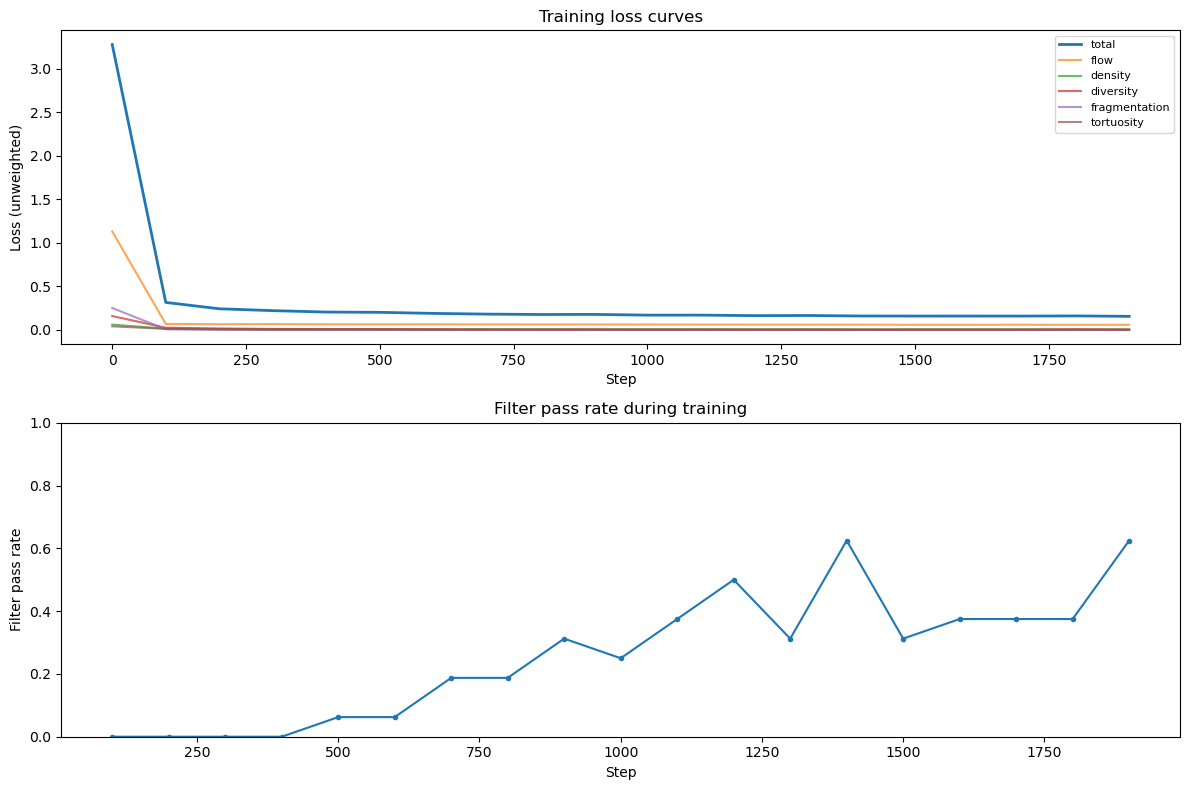

In [83]:
# Plot training curves
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

steps = [h["step"] for h in history]
axes[0].plot(steps, [h["total_loss"] for h in history], label="total", linewidth=2)
for key in ["flow_loss", "density_loss", "diversity_loss", "fragmentation_loss", "tortuosity_loss"]:
    axes[0].plot(steps, [h[key] for h in history], label=key.replace("_loss", ""), alpha=0.7)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss (unweighted)")
axes[0].legend(fontsize=8)
axes[0].set_title("Training loss curves")

pass_rates = [h["filter_pass_rate"] for h in history if not np.isnan(h["filter_pass_rate"])]
pass_steps = [h["step"] for h in history if not np.isnan(h["filter_pass_rate"])]
axes[1].plot(pass_steps, pass_rates, marker="o", markersize=3)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Filter pass rate")
axes[1].set_ylim(0, 1)
axes[1].set_title("Filter pass rate during training")

plt.tight_layout()
plt.show()

=== Raw CNN output stats ===
  shape:  (100, 200)
  min:    0.0000
  max:    1.0000
  mean:   0.3761

=== After threshold (0.5) ===
  solid density: 0.3454  (valid range: 0.15–0.8)
  density_ok:    True

=== Filter report ===
  solid_density: 0.3454
  density_ok: True
  has_flow_path: True
  no_enclosed_fluid: False
  valid: False


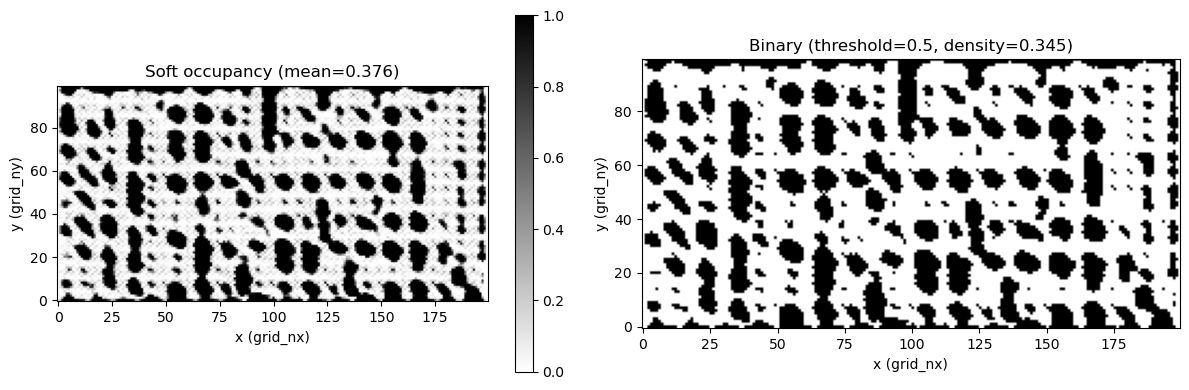

In [84]:
# Run the diagnostic to visualize the CNN output and filter checks after pretraining.
hx_gen.run_diagnostic()

In [85]:
# Run this in a separate cell to diagnose the density issue
hx_gen.cnn.eval()
with torch.no_grad():
    z = torch.randn(4, hx_gen.latent_dim, device=hx_gen.device)
    soft = hx_gen.cnn(z)

for i in range(4):
    g = soft[i, 0]
    soft_mean = g.mean().item()
    hard_mean = (g >= 0.5).float().mean().item()
    print(f"Sample {i}: soft_mean={soft_mean:.4f}  hard_density={hard_mean:.4f}  "
          f"min={g.min().item():.4f}  max={g.max().item():.4f}")

Sample 0: soft_mean=0.3216  hard_density=0.2845  min=0.0000  max=1.0000
Sample 1: soft_mean=0.3197  hard_density=0.2831  min=0.0000  max=1.0000
Sample 2: soft_mean=0.3800  hard_density=0.3450  min=0.0000  max=1.0000
Sample 3: soft_mean=0.3445  hard_density=0.3078  min=0.0000  max=1.0000


In [86]:
# Save the trained weights
trained = False
if trained:
    # Avoid overwriting existing weights if already trained and performance not improved
    hx_gen.save_weights("problems/generator_weights.pth")

In [87]:
# -------------------------------------------------------------
# Heat Exchanger Simulator
# -------------------------------------------------------------
class Simulator:
    def __init__(self, type='MOOSE', params="./cutthroat-opt"):
        self.type = type
        if self.type == 'MOOSE':
            self.app_name = params
        else:
            pass

    def run_moose(self, input_file, n_processors=1):
        '''Run a MOOSE simulation inside a subprocess
        
        Parameters:
        input_file: str, path to the MOOSE input file (.i)
        n_processors: int, number of processors to use for the simulation
        '''
        # Construct the command to run MOOSE
        cmd = [
            "conda", "run", "-n", "moose",
            "mpiexec", "-np", str(n_processors),
            self.app_name, "-i", input_file
        ]

        # Run the command and capture the output
        result = subprocess.run(cmd, capture_output=True, text=True)

        # Check for errors
        if result.returncode != 0:
            print("Error running MOOSE:")
            print(result.stderr)
        else:
            print("MOOSE simulation completed successfully.")
            print(result.stdout)

    def analyze_exodus_results(self, exodus_file):
        # Placeholder for analyzing Exodus results
        # This function would read the Exodus file, extract relevant data, and perform analysis
        mesh = pv.read(exodus_file)
        print(mesh)
        print(mesh.array_names)
    
    def run(self, input_file, n_processors=4):
        if self.type == 'MOOSE':
            self.run_moose(input_file, n_processors)
        else:
            pass

In [88]:
MOOSE_sim = Simulator(type='MOOSE', params="./cutthroat-opt")

In [89]:
# -------------------------------------------------------------
# Optimizer class that ties everything together
# -------------------------------------------------------------

class Optimizer:
    def __init__(self, 
                 domain_dimensions=[0.16, 0.06, 80, 30], 
                 generator_type='untrained_CNN', 
                 simulator_type='MOOSE', 
                 mesh_files_dir="meshes", 
                 results_dir="results",
                 device="cpu"
                 ):
        self.generator = self.initialize_generator(generator_type, domain_dimensions)
        self.simulator = self.initialize_simulator(simulator_type)
        self.mesh_files_dir = mesh_files_dir
        self.results_dir = results_dir
        self.device = device
        
    def initialize_generator(self, generator_type, domain_dimensions):
        gen = HeatExchangerGenerator(grid_nx=domain_dimensions[2],
            grid_ny=domain_dimensions[3],
            domain_length=domain_dimensions[0],
            domain_height=domain_dimensions[1],
            latent_dim=32,
            threshold=0.5,
            device=device,
            min_density=0.15,
            max_density=0.80,
            mesh_params={
                "mesh_algorithm": 8,
                "mesh_recombine": 1,
                "mesh_element_order": 2
            }
        )
        if generator_type == 'untrained_CNN':
            gen.pretrain_on_filter(n_steps=3000, batch_size=16, lr=1e-3, log_every=100)
        elif generator_type == 'pretrained_CNN':
            gen.load_weights("problems/generator_weights.pth")
        return gen
    
    def initialize_simulator(self, simulator_type):
        sim = Simulator(type=simulator_type)
        return sim

    def create_input_file(self, template_path, output_dir, mesh_name):
        '''Generate a MOOSE .i file from a template
        
        Parameters:
        - template_path: path to template.i file
        - output_dir: directory to save the generated .i file
        - mesh_name: name of the mesh file to read e.g. 'rd0001.msh'
        '''
        # Extract case prefix and number from mesh_name (assumes format 'rdXXXX.msh' or 'gdXXXX.msh')
        case_prefix = mesh_name.split('.')[0][:-4]
        case_number = mesh_name.split('.')[0][-4:]
        case_id = f"{case_prefix}{case_number}"

        input_filename = f"{case_id}.i"

        # Load the template
        with open(template_path, "r") as f:
            template = Template(f.read())
        
        # Render the template with the mesh name
        rendered = template.render(
            mesh_name=mesh_name,
            case_name=case_id,
            rho=1.0,  # Placeholder value for density
            mu=1.0,   # Placeholder value for viscosity
            k=1.0,    # Placeholder value for thermal conductivity
            cp=1.0    # Placeholder value for specific heat capacity
        )

        # Ensure output directory exists
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        # Write file to output directory
        output_path = output_dir / input_filename
        with open(output_path, "w") as f:
            f.write(rendered)
        
        return output_path

    def clean_input_file(self, input_file):
        '''Delete the generated .i file after simulation'''
        if os.path.exists(input_file):
            os.remove(input_file)

    def run_simulation(self, input_file, n_processors=None):
        '''Run the simulation using the optimizer's simulator
        
        Parameters:
        - input_file: path to the .i file to run
        - n_processors: number of processors to use for parallel execution if using MOOSE simulator (optional)
        '''
        if n_processors is not None:
            self.simulator.run(input_file, n_processors)
        else:
            self.simulator.run(input_file)

    def simulate_all_meshes(self):
        '''Simulate all meshes in the mesh_files_dir'''
        mesh_files = [f for f in os.listdir(self.mesh_files_dir) if f.endswith('.msh')]
        result_files = [r for r in os.listdir(self.results_dir) if r.endswith('.e')]
        for mesh_file in mesh_files:
            if any(mesh_file.split('.')[0] in result for result in result_files):
                print(f"Results already exist for mesh: {mesh_file}, skipping simulation.")
                continue
            print(f"Simulating for mesh: {mesh_file}")
            input_file = self.create_input_file(
                template_path="problems/template.i",
                output_dir=self.results_dir,
                mesh_name=mesh_file
            )
            self.run_simulation(input_file, n_processors=4)
            self.clean_input_file(input_file)
        